---
### Title: ML_Production Workshop Assignment.
---

Dataset: R. Fisher. "Iris," UCI Machine Learning Repository, 1936. [Online]. Available: https://doi.org/10.24432/C56C76.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import pickle 
import seaborn as sb

In [4]:
column=[
    "sepal_length",
    "sepal_width",
    "petal_length",
    "petal_width",
    "class"
]

raw_data=pd.read_csv('iris/iris.data',header=None,names=column)

In [5]:
raw_data.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


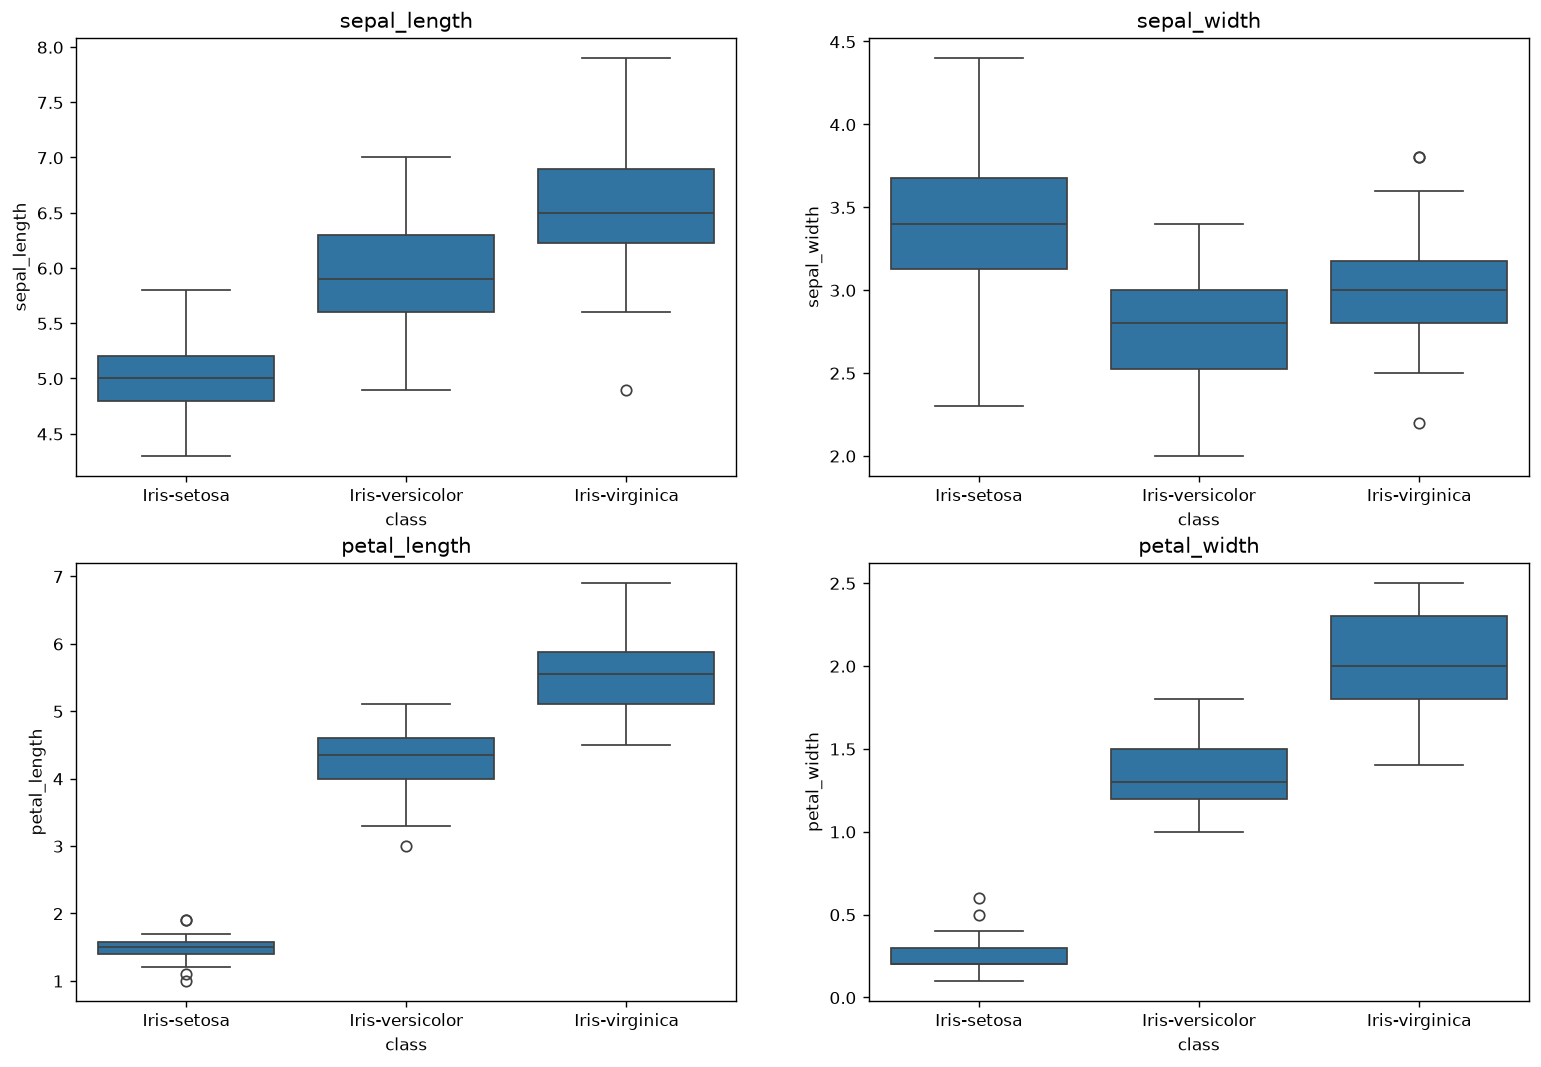

In [6]:
fig,ax=plt.subplots(2,2, figsize=(15,10))
for axis, feature in zip(ax.flat,column):
    sb.boxplot(data=raw_data,x='class',y=feature,ax=axis)
    axis.set_title(feature)
plt.show()




In [12]:
from sklearn.model_selection import train_test_split

# Splitting data into 80% training and 20% testing
y=raw_data['class']
X=raw_data.drop('class',axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [17]:
from sklearn.ensemble import RandomForestClassifier as rfc
from sklearn.metrics import accuracy_score
model=rfc(max_depth=3,random_state=48)
model.fit(X_train,y_train)

y_pred=model.predict(X_test)

print(accuracy_score(y_pred,y_test))



1.0


In [ ]:
joblib.dump(model,iris_model.pkl)